# Notebook 6 - Evaluation Expansion

This notebook expands the final model evaluation beyond top-line test metrics by comparing Linear Regression, Decision Tree, Random Forest, XGBoost, and LightGBM on the untouched June 2026 testing month.

The workflow reloads the fitted models from Notebooks 3-5, verifies the saved feature schema, reports R², MAE, MAPE, MdAPE, and RMSE, and examines performance across actual close-price quintiles. It also evaluates median prediction residuals and the distribution of property-level absolute percentage errors.

These analyses identify which model performs best overall, where performance changes by price level, whether models systematically overpredict or underpredict, and how strongly large errors affect each model.

## Week 8 Summary

- Loaded all five saved final models and verified that the testing feature schema matches the training schema.
- Evaluated every model on the same untouched June 2026 testing month using R², MAE, MAPE, MdAPE, and RMSE.
- Compared overall model performance using separate charts for R², percentage errors, and dollar errors.
- Divided actual ClosePrice into five quintiles and compared MdAPE across models and price bands.
- Examined median residuals to identify systematic overprediction and underprediction by price band.
- Compared the distribution of property-level absolute percentage errors using median, P90, and P95 statistics.
- Exported `metrics_summary.csv` as the required Week 8 model scorecard.

## Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "validation_encoded": data_dir / f"validation_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
validation_encoded_df = dfs["validation_encoded"]
test_encoded_df = dfs["test_encoded"]

# Read the retained transaction periods for an exact split summary
period_source = pd.read_csv(
    data_dir / f"cleaned_crmls_{TRAIN_MONTHS}m.csv",
    usecols = ["ClosePeriod"]
)
available_periods = pd.PeriodIndex(
    period_source["ClosePeriod"].dropna().astype(str),
    freq = "M"
).unique().sort_values()
test_period = available_periods.max()
validation_period = test_period - 1
training_periods = available_periods[available_periods < validation_period]

print(
    f"Training: {training_periods.min()} to {training_periods.max()} "
    f"({len(training_periods)} months)"
)
print(f"Validation: {validation_period} (1 month)")
print(f"Test: {test_period} (1 month)")

Training: 2023-11 to 2026-04 (30 months)
Validation: 2026-05 (1 month)
Test: 2026-06 (1 month)


In [4]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Validation set - used only for model/hyperparameter selection
x_validation = validation_encoded_df.drop(columns = ["ClosePrice"])
y_validation = validation_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]
# Final training data used only after all choices are frozen
x_train_final = pd.concat([x_train, x_validation], ignore_index = True)
y_train_final = pd.concat([y_train, y_validation], ignore_index = True)

In [5]:
print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(317384, 127)
(11646, 127)
(12442, 127)


## Models

The saved Linear Regression, Decision Tree, Random Forest, XGBoost, and LightGBM models are loaded from `../models/`. Before prediction, the notebook verifies that all required files exist and that the test feature names and order match the schema saved during training.

In [6]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [7]:
# Path of each model
model_dir = Path("../models")
linear_model_path = model_dir / "linear_regression.joblib"
feature_schema_path = model_dir / "model_features.joblib"
decision_tree_model_path = model_dir / "decision_tree.joblib"
random_forest_model_path = model_dir / "random_forest.joblib"
xgboost_model_path = model_dir / "xgboost.joblib"
lightgbm_model_path = model_dir / "lightgbm.joblib"
# Double Check all models exist
if not linear_model_path.exists() or not feature_schema_path.exists():
    raise FileNotFoundError(
        "Run Notebook 3 first to create the Linear Regression model and feature schema."
    )
if not decision_tree_model_path.exists() or not random_forest_model_path.exists():
    raise FileNotFoundError(
        "Run Notebook 4 first to create the Decision Tree model and Random Forest Model."
    )
if not xgboost_model_path.exists() or not lightgbm_model_path.exists():
    raise FileNotFoundError(
        "Run Notebook 5 first to create the XGBoost model and LightGBM Model."
    )
# Double check the test set's features are the same
model_features = joblib.load(feature_schema_path)
if list(x_test.columns) != model_features:
    raise ValueError(
        "The test feature columns do not match the schema used by the saved model."
    )
# Load each final model & get evaluation
# Linear Regression
lr_regressor = joblib.load(linear_model_path)
y_pred_lr = lr_regressor.predict(x_test)
r2_lr, mae_lr, mape_lr, mdape_lr, rmse_lr = evaluation(y_test, y_pred_lr)
print("Loaded the saved Linear Regression model.")
# Decision Tree
dt_regressor = joblib.load(decision_tree_model_path)
y_pred_dt = dt_regressor.predict(x_test)
r2_dt, mae_dt, mape_dt, mdape_dt, rmse_dt = evaluation(y_test, y_pred_dt)
print("Loaded the saved Decision Tree model.")
# Random Forest
rf_regressor = joblib.load(random_forest_model_path)
y_pred_rf = rf_regressor.predict(x_test)
r2_rf, mae_rf, mape_rf, mdape_rf, rmse_rf = evaluation(y_test, y_pred_rf)
print("Loaded the saved Random Forest model.")
# XGBoost
xgb_regressor = joblib.load(xgboost_model_path)
y_pred_xgb = xgb_regressor.predict(x_test)
r2_xgb, mae_xgb, mape_xgb, mdape_xgb, rmse_xgb = evaluation(y_test, y_pred_xgb)
print("Loaded the saved XGBoost model.")
# LightGBM
lgbm_regressor = joblib.load(lightgbm_model_path)
y_pred_lgbm = lgbm_regressor.predict(x_test)
r2_lgbm, mae_lgbm, mape_lgbm, mdape_lgbm, rmse_lgbm = evaluation(y_test, y_pred_lgbm)
print("Loaded the saved LightGBM model.")

Loaded the saved Linear Regression model.
Loaded the saved Decision Tree model.
Loaded the saved Random Forest model.
Loaded the saved XGBoost model.
Loaded the saved LightGBM model.


## Metrics Summary Table

The table reports all five final models on the same untouched June 2026 test set. Higher R² is better; lower MAE, MAPE, MdAPE, and RMSE are better.

In [8]:
metrics_summary = pd.DataFrame({
        "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM"],
        "R²": [r2_lr, r2_dt, r2_rf, r2_xgb, r2_lgbm],
        "MAE": [mae_lr, mae_dt, mae_rf, mae_xgb, mae_lgbm],
        "MAPE (%)": [mape_lr, mape_dt, mape_rf, mape_xgb, mape_lgbm],
        "MdAPE (%)": [mdape_lr, mdape_dt, mdape_rf, mdape_xgb, mdape_lgbm],
        "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_xgb, rmse_lgbm]
    })

metrics_summary.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6409,"$358,818.47",33.0190%,24.9885%,"$588,365.25"
Decision Tree,0.8134,"$210,000.70",15.5529%,10.1457%,"$424,092.20"
Random Forest,0.8746,"$168,733.01",12.4580%,7.9310%,"$347,627.59"
XGBoost,0.9009,"$160,000.81",12.5889%,8.3710%,"$309,013.08"
LightGBM,0.9060,"$156,025.13",12.1622%,8.3320%,"$301,065.10"


In [9]:
models = metrics_summary["Model"]
r2 = metrics_summary["R²"]
mae = metrics_summary["MAE"]
mape = metrics_summary["MAPE (%)"]
mdape = metrics_summary["MdAPE (%)"]
rmse = metrics_summary["RMSE"]

## Overall R² Comparison

R² measures the proportion of test-set ClosePrice variance explained by each model. The boosted models provide the strongest overall fit, with LightGBM narrowly ahead of XGBoost.

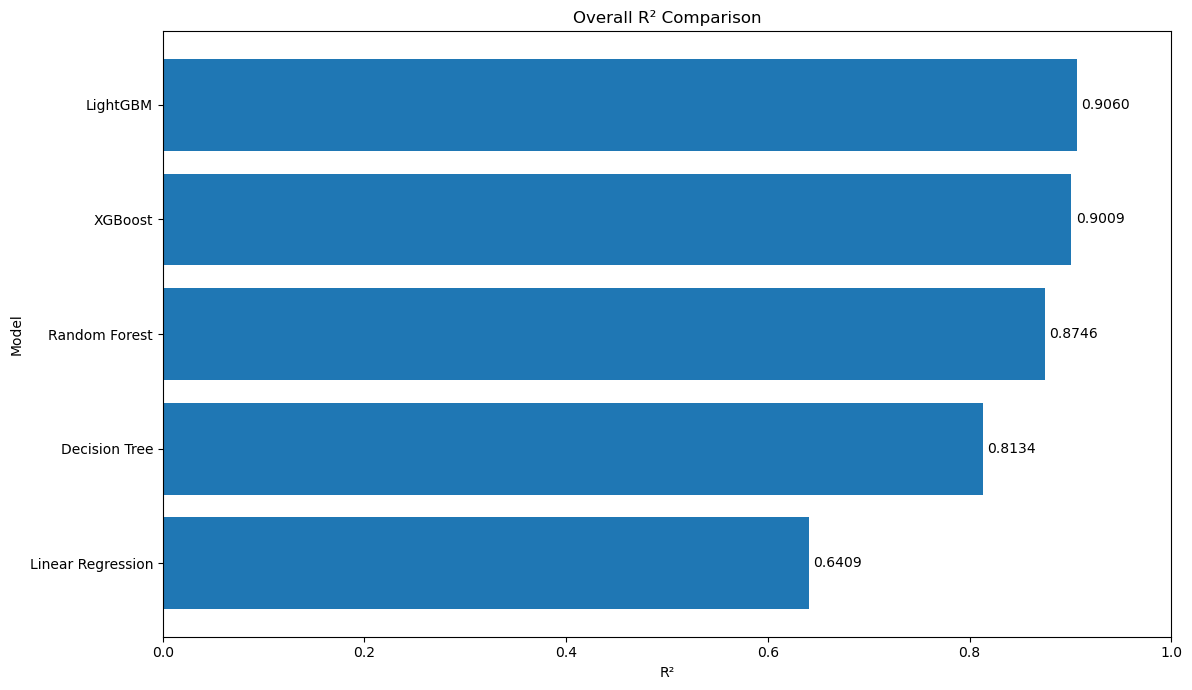

In [10]:
plt.figure(figsize = (12, 7))
r2_bars = plt.barh(models, r2)
plt.xlabel("R²")
plt.ylabel("Model")
plt.title("Overall R² Comparison")
plt.bar_label(r2_bars, fmt = '%.4f', padding = 3)
plt.tight_layout()
plt.xlim(0, 1)
plt.show()

## MAPE vs. MdAPE Comparison

MAPE summarizes the mean property-level percentage error and is more sensitive to large misses. MdAPE reports the median property-level percentage error and better represents the typical property. The lower MdAPE values relative to MAPE indicate right-skewed error distributions across all models.

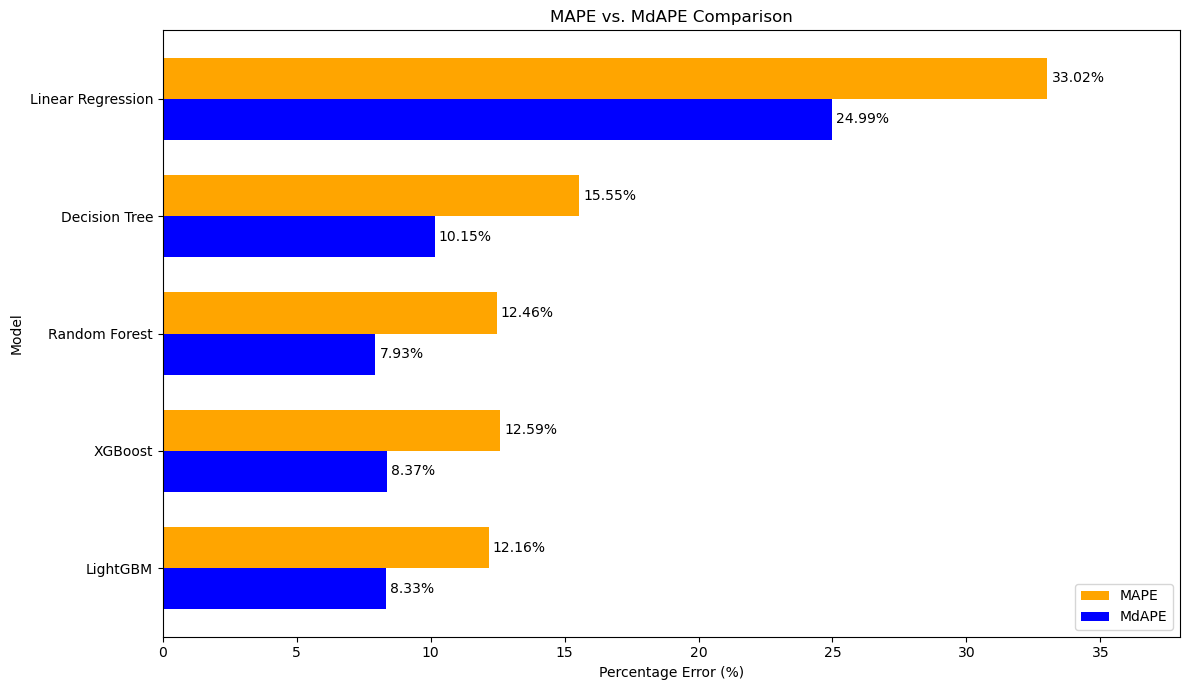

In [11]:
y_position = np.arange(len(models))
bar_height = 0.35

fig, ax = plt.subplots(figsize = (12, 7))

mape_bars = ax.barh(
    y_position - bar_height / 2,
    mape,
    height = bar_height,
    label = "MAPE",
    color = "Orange"
)
mdape_bars = ax.barh(
    y_position + bar_height / 2,
    mdape,
    height = bar_height,
    label = "MdAPE",
    color = "Blue"
)

ax.set_yticks(y_position)
ax.set_yticklabels(models)
ax.set_xlabel("Percentage Error (%)")
ax.set_ylabel("Model")
ax.set_title("MAPE vs. MdAPE Comparison")
ax.legend()

ax.bar_label(mape_bars, fmt = "%.2f%%", padding = 3)
ax.bar_label(mdape_bars, fmt = "%.2f%%", padding = 3)
ax.invert_yaxis()
ax.set_xlim(0, max(mape.max(), mdape.max()) * 1.15)
plt.tight_layout()
plt.show()

## MAE vs. RMSE Comparison

MAE reports the average absolute dollar error, while RMSE places more weight on large dollar misses. RMSE exceeds MAE for every model, confirming that a smaller set of difficult properties creates substantial tail error.

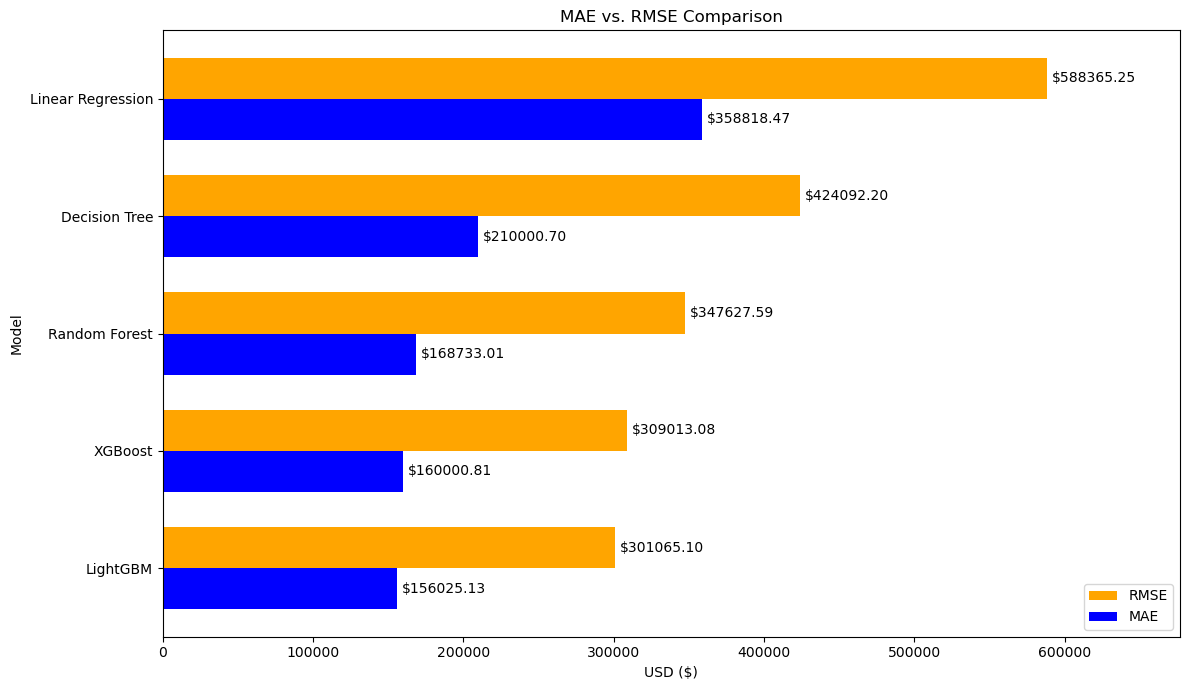

In [12]:
y_position = np.arange(len(models))
bar_height = 0.35

fig, ax = plt.subplots(figsize = (12, 7))

mape_bars = ax.barh(
    y_position - bar_height / 2,
    rmse,
    height = bar_height,
    label = "RMSE",
    color = "Orange"
)
mdape_bars = ax.barh(
    y_position + bar_height / 2,
    mae,
    height = bar_height,
    label = "MAE",
    color = "Blue"
)

ax.set_yticks(y_position)
ax.set_yticklabels(models)
ax.set_xlabel("USD ($)")
ax.set_ylabel("Model")
ax.set_title("MAE vs. RMSE Comparison")
ax.legend()

ax.bar_label(mape_bars, fmt = "$%.2f", padding = 3)
ax.bar_label(mdape_bars, fmt = "$%.2f", padding = 3)
ax.invert_yaxis()
ax.set_xlim(0, max(mae.max(), rmse.max()) * 1.15)
plt.tight_layout()
plt.show()

## Price-Band MdAPE Heatmap

The test properties are divided into five quintiles using actual ClosePrice. Each cell reports the median APE for one model and price band. Random Forest performs best in Q1-Q3, XGBoost is marginally best in Q4, and LightGBM is best in Q5. All non-linear models show higher typical error in the highest-price quintile than in the middle-price bands.

In [13]:
prediction_df = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm
})
price_band_labels = [
    "Q1 - Lowest",
    "Q2 - Low",
    "Q3 - Middle",
    "Q4 - High",
    "Q5 - Highest"
]
# Divide into 5 bands
prediction_df["Price Band"] = pd.qcut(
    prediction_df["Actual"],
    q = 5,
    labels = price_band_labels
)
prediction_df.head()

,Actual,Linear Regression,Decision Tree,Random Forest,XGBoost,LightGBM,Price Band
0,2250000.0,1.778899e+06,2.018000e+06,2.166779e+06,1.963458e+06,2.017625e+06,Q5 - Highest
1,851000.0,1.714888e+06,8.555714e+05,9.058318e+05,7.961193e+05,9.301143e+05,Q3 - Middle
2,950000.0,1.219223e+06,9.929375e+05,9.075274e+05,1.108833e+06,1.082416e+06,Q3 - Middle
3,245000.0,-1.689089e+04,2.218000e+05,2.871348e+05,2.888503e+05,2.930262e+05,Q1 - Lowest
4,1175000.0,9.852011e+05,1.134349e+06,1.211644e+06,1.248718e+06,1.269047e+06,Q4 - High


In [14]:
model_names = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "LightGBM"
]
# Calculate APE = |Actual Price - Predicted Price| / Actual Price * 100
ape_columns = []
for model_name in model_names:
    ape_column = f"{model_name} APE"
    prediction_df[ape_column] = (np.abs(prediction_df["Actual"] - prediction_df[model_name]) / prediction_df["Actual"] * 100)
    ape_columns.append(ape_column)
# Group by Price Band
price_band_mdape = (
    prediction_df
    .groupby("Price Band", observed = False)[ape_columns]
    .median()
)
# Simplify columns' names
price_band_mdape.columns = model_names
# Heatmap data
heatmap_data = price_band_mdape.T

heatmap_data

Price Band,Q1 - Lowest,Q2 - Low,Q3 - Middle,Q4 - High,Q5 - Highest
Linear Regression,38.743588,28.817541,23.684152,18.313696,21.758471
Decision Tree,9.334566,7.672320,9.074055,11.003774,14.975962
Random Forest,7.243216,5.706178,7.296107,8.903276,12.057209
XGBoost,8.590727,6.642861,7.566493,8.728527,11.095073
LightGBM,8.674589,6.613657,7.512312,8.853673,10.866348


In [15]:
price_band_summary = (
    prediction_df
    .groupby("Price Band", observed = False)["Actual"]
    .agg(["count", "min", "median", "max"])
)

price_band_summary.style.format({
    "min": "${:,.0f}",
    "median": "${:,.0f}",
    "max": "${:,.0f}"
})

,count,min,median,max
Price Band,,,,
Q1 - Lowest,2531,"$190,000","$450,000","$575,000"
Q2 - Low,2496,"$575,772","$697,950","$800,000"
Q3 - Middle,2485,"$801,000","$925,000","$1,100,000"
Q4 - High,2455,"$1,100,005","$1,335,000","$1,650,000"
Q5 - Highest,2475,"$1,652,500","$2,330,000","$8,200,000"


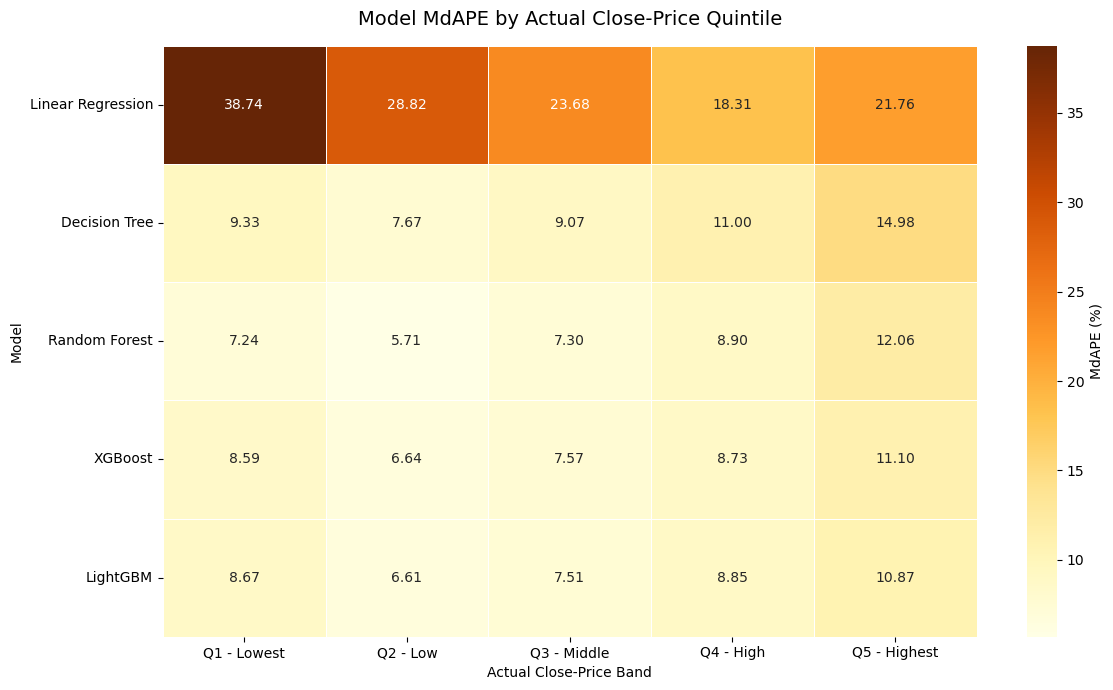

In [16]:
plt.figure(figsize = (12, 7))

ax = sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = ".2f",
    cmap = "YlOrBr",
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws = {"label": "MdAPE (%)"}
)

ax.set_title(
    "Model MdAPE by Actual Close-Price Quintile",
    fontsize = 14,
    pad = 15
)
ax.set_xlabel("Actual Close-Price Band")
ax.set_ylabel("Model")

plt.tight_layout()
plt.show()

## Median Residual by Price Band

Residual is defined as `Actual Price - Predicted Price`. Positive values indicate underprediction and negative values indicate overprediction. The heatmap shows limited median bias for the boosted models in Q1-Q4, but all five models underpredict Q5; XGBoost has the smallest median Q5 underprediction at approximately $101,000.

In [17]:
# Calculate residual = Actual Price - Predicted Price
# Positive residual: underprediction
# Negative residual: overprediction
mr_columns = []
for model_name in model_names:
    mr_column = f"{model_name} Residual"
    prediction_df[mr_column] = (prediction_df["Actual"] - prediction_df[model_name])
    mr_columns.append(mr_column)
# Group by Price Band
price_band_mr = (
    prediction_df
    .groupby("Price Band", observed = False)[mr_columns]
    .median()
)
# Simplify columns' names
price_band_mr.columns = model_names
# Heatmap data
heatmap_data_mr = price_band_mr.T
heatmap_data_mr

Price Band,Q1 - Lowest,Q2 - Low,Q3 - Middle,Q4 - High,Q5 - Highest
Linear Regression,-20709.569303,-99868.232612,-178701.017803,-104986.157641,380689.417846
Decision Tree,-12999.833333,-5999.088608,10152.295977,25172.413793,167279.600000
Random Forest,-11734.674251,-5477.215634,516.216965,7928.199456,139661.946085
XGBoost,-2122.250000,-1127.312500,-6198.500000,-3227.500000,101432.750000
LightGBM,-11791.359647,-4416.580626,-8916.644016,-2957.640654,106676.493125


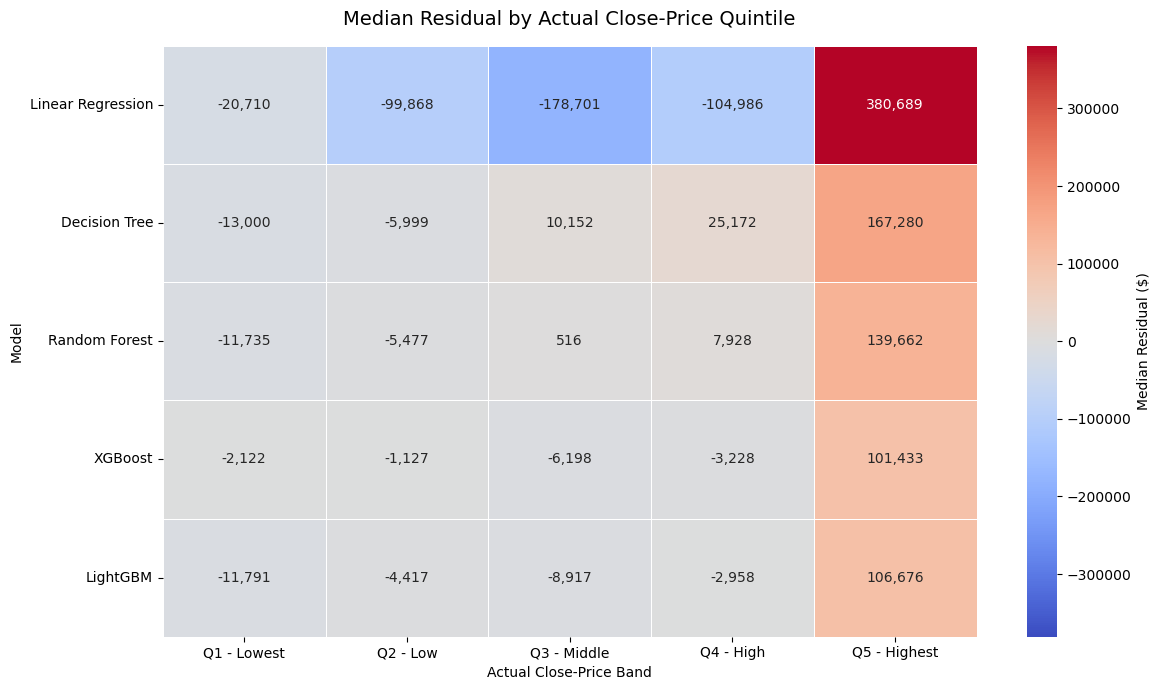

In [18]:
# Use a symmetric color scale around zero
max_absolute_residual = np.abs(heatmap_data_mr.to_numpy()).max()
plt.figure(figsize = (12, 7))
ax = sns.heatmap(
    heatmap_data_mr,
    annot = True,
    fmt = ",.0f",
    cmap = "coolwarm",
    center = 0,
    vmin = -max_absolute_residual,
    vmax = max_absolute_residual,
    linewidths = 0.5,
    linecolor = "white",
    cbar_kws = {"label": "Median Residual ($)"}
)
ax.set_title(
    "Median Residual by Actual Close-Price Quintile",
    fontsize = 14,
    pad = 15
)
ax.set_xlabel("Actual Close-Price Band")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## APE Distribution by Model

The boxplot compares the distribution of property-level absolute percentage errors. The line inside each box is the model's MdAPE. Random Forest has the lowest median, while LightGBM has the lowest P95 APE, indicating better control of the upper error tail. Individual outlier points are hidden from the visualization for readability, but all observations remain included in the metric and percentile calculations.

In [19]:
ape_long = (
    prediction_df[ape_columns]
    .rename(columns = dict(zip(ape_columns, model_names)))
    .melt(
        var_name = "Model",
        value_name = "APE"
    )
)
ape_long.head()

,Model,APE
0,Linear Regression,20.937819
1,Linear Regression,101.514511
2,Linear Regression,28.339284
3,Linear Regression,106.894241
4,Linear Regression,16.153099


In [20]:
ape_distribution_summary = (
    ape_long
    .groupby("Model")["APE"]
    .agg(
        Count = "size",
        Mean = "mean",
        Median = "median",
        P90 = lambda values: values.quantile(0.90),
        P95 = lambda values: values.quantile(0.95)
    )
    .reindex(model_names)
)

ape_distribution_summary.style.format({
    "Mean": "{:.2f}%",
    "Median": "{:.2f}%",
    "P90": "{:.2f}%",
    "P95": "{:.2f}%"
})

,Count,Mean,Median,P90,P95
Model,,,,,
Linear Regression,12442,33.02%,24.99%,68.25%,88.56%
Decision Tree,12442,15.55%,10.15%,33.92%,46.93%
Random Forest,12442,12.46%,7.93%,28.12%,37.90%
XGBoost,12442,12.59%,8.37%,26.93%,37.64%
LightGBM,12442,12.16%,8.33%,26.09%,35.45%


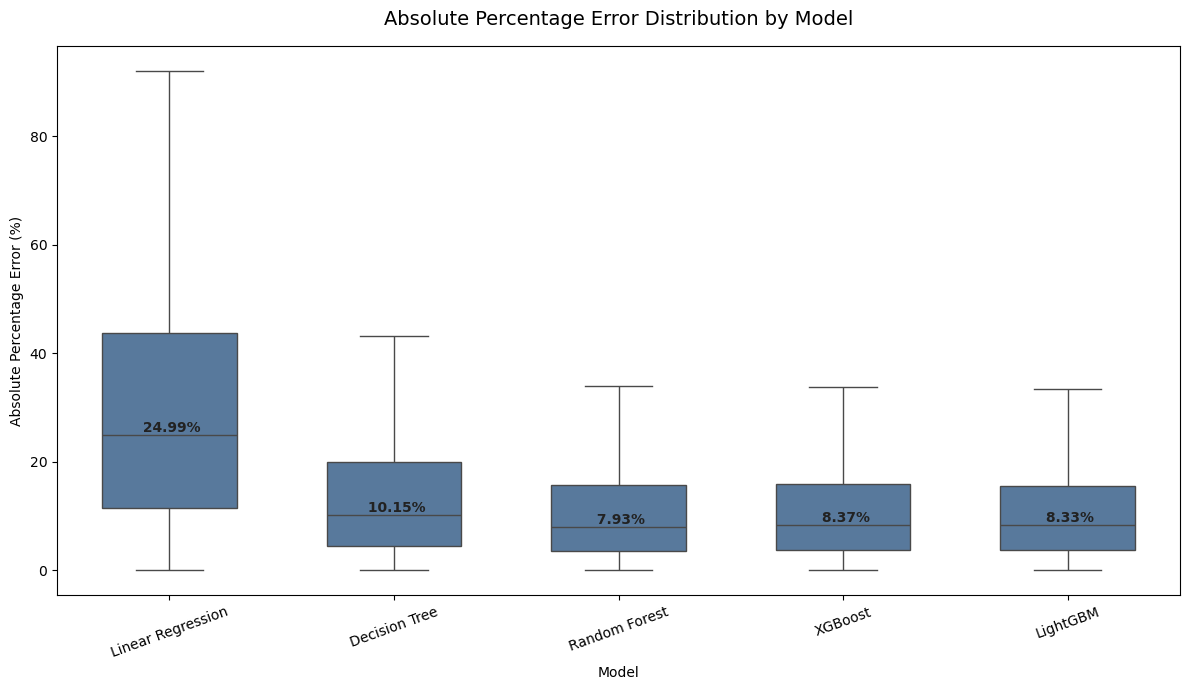

In [21]:
model_medians = (
    ape_long
    .groupby("Model")["APE"]
    .median()
    .reindex(model_names)
)

plt.figure(figsize = (12, 7))

ax = sns.boxplot(
    data = ape_long,
    x = "Model",
    y = "APE",
    order = model_names,
    color = "#4C78A8",
    showfliers = False,
    width = 0.6
)

for position, median_value in enumerate(model_medians):
    ax.text(
        position,
        median_value,
        f" {median_value:.2f}%",
        ha = "center",
        va = "bottom",
        color = "#222222",
        fontweight = "bold"
    )
    
ax.set_title(
    "Absolute Percentage Error Distribution by Model",
    fontsize = 14,
    pad = 15
)
ax.set_xlabel("Model")
ax.set_ylabel("Absolute Percentage Error (%)")
ax.tick_params(axis = "x", rotation = 20)
plt.tight_layout()
plt.show()

## Evaluation Summary

All five models were evaluated using the same chronological train/validation/test design and the same untouched June 2026 testing month. LightGBM achieved the strongest overall R² (0.9060), MAE (USD 156,025.13), MAPE (12.1622%), and RMSE (USD 301,065.10). Random Forest retained the lowest MdAPE at 7.9310%, compared with 8.3320% for LightGBM, indicating that Random Forest remained slightly better for the typical percentage error.

Performance varied across actual close-price quintiles. Random Forest achieved the lowest MdAPE in the three lowest quintiles, XGBoost was marginally strongest in the fourth quintile, and LightGBM was strongest in the highest quintile. The highest-price quintile, approximately USD 1.65 million to USD 8.20 million in this testing month, remained the most difficult segment for the non-linear models.

Using the residual definition `Actual Price - Predicted Price`, all five models produced positive median residuals in the highest-price quintile, indicating systematic underprediction. XGBoost produced the smallest median underprediction in that band at approximately USD 101,433, followed by LightGBM at approximately USD 106,676.

The property-level APE distribution reinforces the distinction between typical and tail performance. Random Forest achieved the lowest median APE, while LightGBM achieved the lowest P90 and P95 APE. LightGBM therefore provided the strongest overall fit and better control of severe percentage errors, while Random Forest remained strongest for the median property.

### Limitations

- Results represent one held-out month and do not by themselves demonstrate stability across multiple market periods. Rolling-origin evaluation would provide stronger temporal evidence.
- Price bands are testing-month quintiles rather than fixed business thresholds, so their dollar boundaries will change when the evaluation dataset changes.
- Dollar residuals naturally increase with property value and should be interpreted alongside percentage-based metrics.
- Boxplot outlier markers are hidden for readability, although all observations remain included in the reported metrics and percentiles.
- These results describe predictive performance and should not be interpreted as causal evidence about individual property features.

## Export Summary CSV

The required Week 8 model scorecard is exported as `metrics_summary.csv`.

In [22]:
results_dir = Path("../data/results")
results_dir.mkdir(parents = True, exist_ok = True)
metrics_summary.to_csv(
    "../data/results/metrics_summary.csv",
    index = False
)
# price_band_mdape.to_csv(
#     results_dir / "price_band_mdape.csv"
# )

# prediction_df.to_csv(
#     results_dir / "test_predictions.csv",
#     index = False
# )

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship